/home/ibeckett/.local/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.9.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


(3000, 13)
   task_id  rep    n  p  p_eff  corr       auc  ci_width  ci_lower  ci_upper  \
0        1    1  100  5    5.0   0.0  0.891114  0.157812  0.814621  0.972433   
1        2    2  100  5    5.0   0.0  0.887054  0.175781  0.776730  0.952511   
2        3    3  100  5    5.0   0.0  0.769796  0.239253  0.619627  0.858880   
3        4    4  100  5    5.0   0.0  0.855222  0.127000  0.788778  0.915778   
4        5    5  100  5    5.0   0.0  0.815179  0.196987  0.728627  0.925614   

   selected_mtry  selected_ntree  class_balance  
0              5             100           0.55  
1              3             400           0.46  
2              1             200           0.56  
3              5             400           0.50  
4              1             400           0.46  


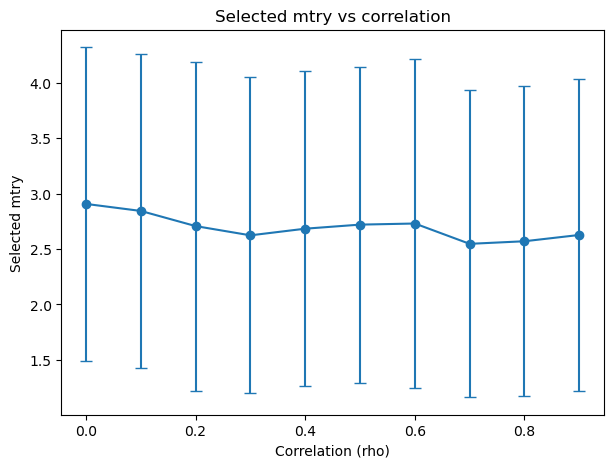

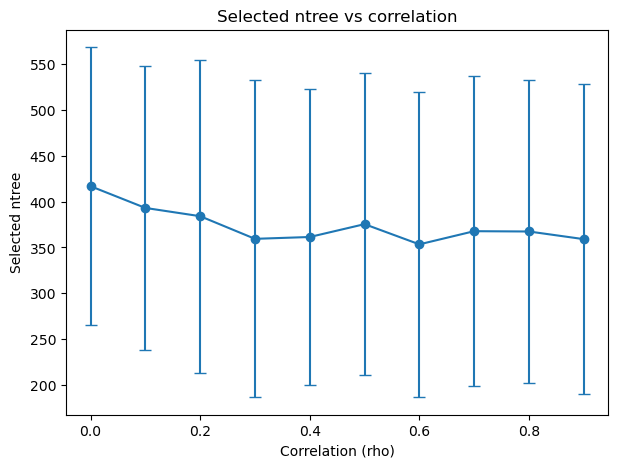

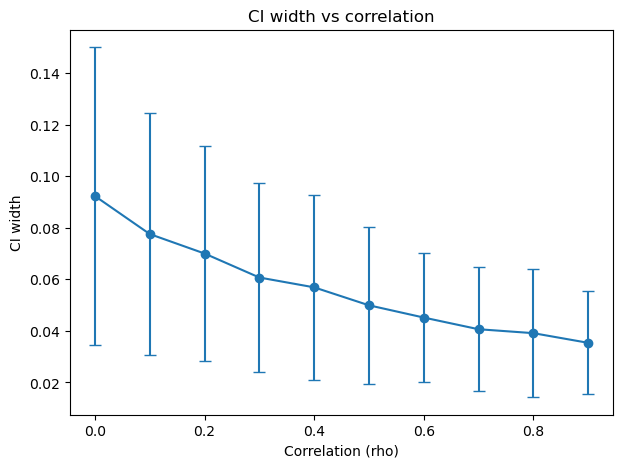

   corr   mtry_sd    ntree_sd   ci_mean  n_obs
0   0.0  1.413488  151.433139  0.092267    300
1   0.1  1.418507  154.262730  0.077535    300
2   0.2  1.483676  170.609766  0.069990    300
3   0.3  1.426501  172.565403  0.060686    300
4   0.4  1.422369  161.011297  0.056874    300
5   0.5  1.424205  164.768680  0.049911    300
6   0.6  1.486989  166.477038  0.045163    300
7   0.7  1.383547  168.966628  0.040633    300
8   0.8  1.396999  164.589960  0.039110    300
9   0.9  1.407323  169.256687  0.035364    300


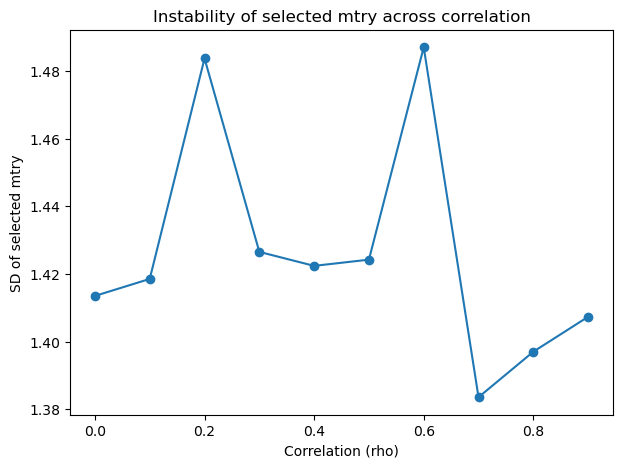

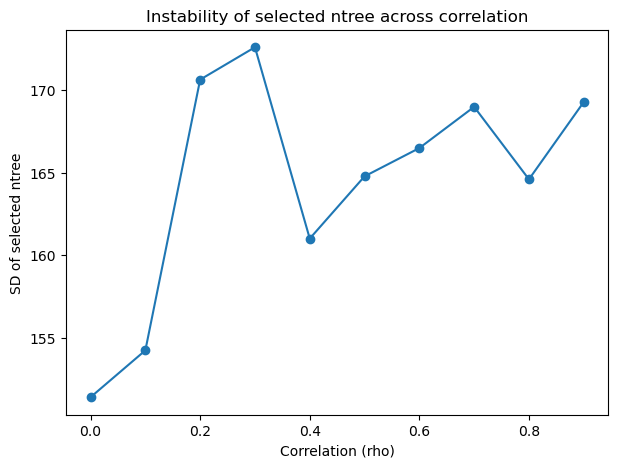

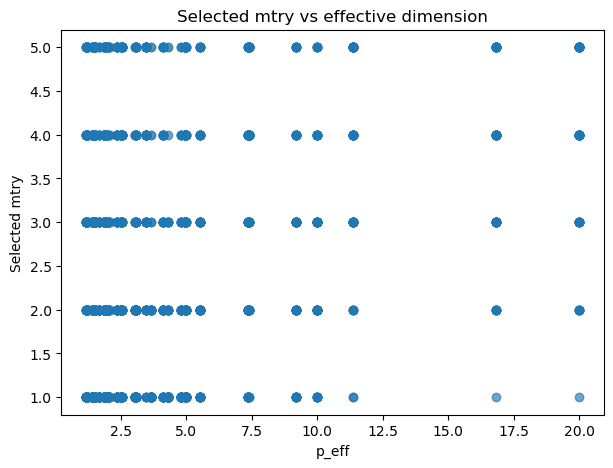

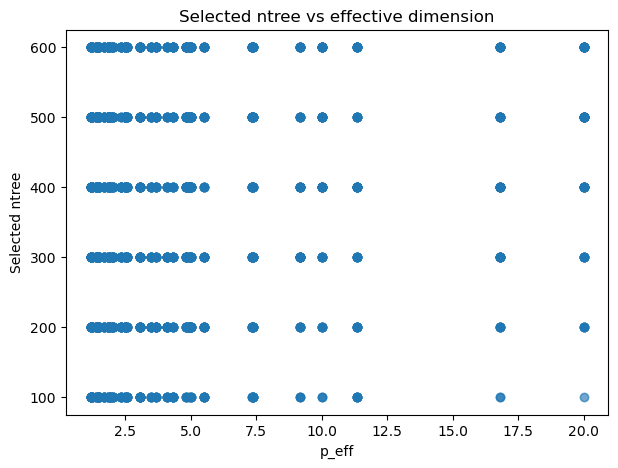

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
# load partial results
df = pd.read_csv("results_full/selected_results.csv")

print(df.shape)
print(df.head())

# make sure corr is sorted numerically
df = df.sort_values(["corr", "n", "p", "rep","p_eff"])

# -----------------------------
# 1) mean selected hyperparams by correlation
# -----------------------------
mtry_summary = df.groupby("corr")["selected_mtry"].agg(["mean", "std", "count"]).reset_index()
ntree_summary = df.groupby("corr")["selected_ntree"].agg(["mean", "std", "count"]).reset_index()
ci_summary = df.groupby("corr")["ci_width"].agg(["mean", "std", "count"]).reset_index()

plt.figure(figsize=(7,5))
plt.errorbar(
    mtry_summary["corr"],
    mtry_summary["mean"],
    yerr=mtry_summary["std"],
    marker="o",
    capsize=4
)
plt.xlabel("Correlation (rho)")
plt.ylabel("Selected mtry")
plt.title("Selected mtry vs correlation")
plt.show()

plt.figure(figsize=(7,5))
plt.errorbar(
    ntree_summary["corr"],
    ntree_summary["mean"],
    yerr=ntree_summary["std"],
    marker="o",
    capsize=4
)
plt.xlabel("Correlation (rho)")
plt.ylabel("Selected ntree")
plt.title("Selected ntree vs correlation")
plt.show()

plt.figure(figsize=(7,5))
plt.errorbar(
    ci_summary["corr"],
    ci_summary["mean"],
    yerr=ci_summary["std"],
    marker="o",
    capsize=4
)
plt.xlabel("Correlation (rho)")
plt.ylabel("CI width")
plt.title("CI width vs correlation")
plt.show()

# -----------------------------
# 2) spread / instability by correlation
# -----------------------------
spread = df.groupby("corr").agg(
    mtry_sd=("selected_mtry", "std"),
    ntree_sd=("selected_ntree", "std"),
    ci_mean=("ci_width", "mean"),
    n_obs=("task_id", "count")
).reset_index()

print(spread)

plt.figure(figsize=(7,5))
plt.plot(spread["corr"], spread["mtry_sd"], marker="o")
plt.xlabel("Correlation (rho)")
plt.ylabel("SD of selected mtry")
plt.title("Instability of selected mtry across correlation")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(spread["corr"], spread["ntree_sd"], marker="o")
plt.xlabel("Correlation (rho)")
plt.ylabel("SD of selected ntree")
plt.title("Instability of selected ntree across correlation")
plt.show()

# -----------------------------
# 3) optional: look at effect of p_eff
# -----------------------------
plt.figure(figsize=(7,5))
plt.scatter(df["p_eff"], df["selected_mtry"], alpha=0.4)
plt.xlabel("p_eff")
plt.ylabel("Selected mtry")
plt.title("Selected mtry vs effective dimension")
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(df["p_eff"], df["selected_ntree"], alpha=0.4)
plt.xlabel("p_eff")
plt.ylabel("Selected ntree")
plt.title("Selected ntree vs effective dimension")
plt.show()

In [2]:
import statsmodels.api as sm
df["ratio_np"] = df["n"] / df["p_eff"]
df["ratio_np2"] = df["ratio_np"] ** 2

df["forest_ratio"] = df["selected_ntree"] / df["selected_mtry"]
df["interaction1"] = df["ratio_np"] * df["corr"]
df["interaction2"] = df["ratio_np2"] * df["corr"]

X = df[
    [
        "ratio_np",
        "ratio_np2",
        "corr",
        "interaction1",
        "interaction2"
    ]
]

X = sm.add_constant(X)

model1 = sm.OLS(df["forest_ratio"], X).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:           forest_ratio   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     5.094
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           0.000118
Time:                        19:57:11   Log-Likelihood:                -19365.
No. Observations:                3000   AIC:                         3.874e+04
Df Residuals:                    2994   BIC:                         3.878e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          159.3596      9.435     16.890   

In [5]:
X = df[["ratio_np","ratio_np2"]]
X = sm.add_constant(X)

model_mtry = sm.OLS(df["selected_mtry"], X).fit()

print(model_mtry.summary())

                            OLS Regression Results                            
Dep. Variable:          selected_mtry   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     13.80
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           1.08e-06
Time:                        05:01:17   Log-Likelihood:                -5312.8
No. Observations:                3000   AIC:                         1.063e+04
Df Residuals:                    2997   BIC:                         1.065e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9128      0.051     57.270      0.0

In [6]:
X = df[["ratio_np","ratio_np2"]]
X = sm.add_constant(X)

model_ntree = sm.OLS(df["selected_ntree"], X).fit()

print(model_ntree.summary())

                            OLS Regression Results                            
Dep. Variable:         selected_ntree   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     4.664
Date:                Mon, 16 Mar 2026   Prob (F-statistic):            0.00949
Time:                        05:01:19   Log-Likelihood:                -19575.
No. Observations:                3000   AIC:                         3.916e+04
Df Residuals:                    2997   BIC:                         3.917e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        389.1785      5.903     65.929      0.0

Text(0, 0.5, 'Residuals')

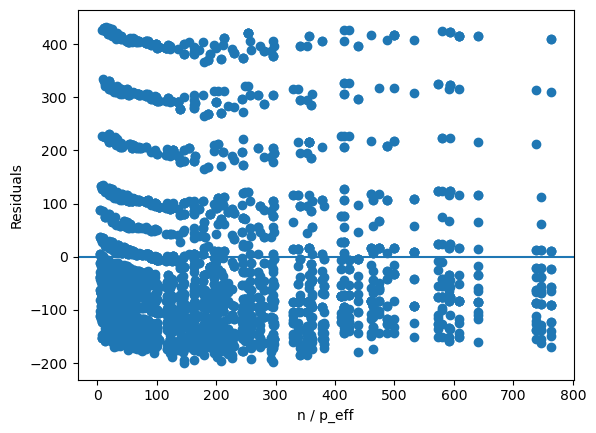

In [7]:
plt.scatter(df["ratio_np"], model1 .resid)
plt.axhline(0)
plt.xlabel("n / p_eff")
plt.ylabel("Residuals")

In [8]:
import statsmodels.formula.api as smf
model = smf.mixedlm(
    "forest_ratio ~ ratio_np + ratio_np2 + corr",
    df,
    groups=df["task_id"]
)

result = model.fit()

print(result.summary())

/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: forest_ratio
No. Observations: 3000    Method:             REML        
No. Groups:       3000    Scale:              11916.6914  
Min. group size:  1       Log-Likelihood:     -19379.3645 
Max. group size:  1       Converged:          Yes         
Mean group size:  1.0                                     
----------------------------------------------------------
             Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept    186.934    6.083 30.728 0.000 175.011 198.857
ratio_np       0.157    0.055  2.830 0.005   0.048   0.265
ratio_np2     -0.000    0.000 -2.819 0.005  -0.000  -0.000
corr         -16.413   13.297 -1.234 0.217 -42.475   9.649
Group Var  11916.691                                      



In [15]:
model3 = smf.mixedlm(
    "forest_ratio ~ ratio_np + ratio_np2 + corr",
    df,
    groups=df["task_id"],
    re_formula="~ratio_np"
)
result = model3.fit()

print(result.summary())

/opt/conda/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

               Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    forest_ratio
No. Observations:    3000       Method:                REML        
No. Groups:          3000       Scale:                 445.1069    
Min. group size:     1          Log-Likelihood:        -20580.1542 
Max. group size:     1          Converged:             No          
Mean group size:     1.0                                           
-------------------------------------------------------------------
                      Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
-------------------------------------------------------------------
Intercept             168.309    4.859 34.636 0.000 158.785 177.833
ratio_np                0.217    0.097  2.246 0.025   0.028   0.407
ratio_np2              -0.000    0.000 -1.931 0.053  -0.001   0.000
corr                   33.880   12.605  2.688 0.007   9.175  58.586
Group Var            4751.022   18.270                         

/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [4]:
import numpy as np
import statsmodels.formula.api as smf
df["ratio"] = df["n"] / df["p_eff"]
df["forest_ratio"] = df["selected_ntree"] / df["selected_mtry"]
df["log_ratio"] = np.log(df["ratio"])
df["log_ratio2"] = df["log_ratio"] ** 2
df["log_forest_ratio"] = np.log(df["forest_ratio"])
model_loglog = smf.ols(
    "log_forest_ratio ~ log_ratio*corr",
    data=df
).fit()

print(model_loglog.summary())

                            OLS Regression Results                            
Dep. Variable:       log_forest_ratio   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     6.380
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           0.000263
Time:                        19:57:57   Log-Likelihood:                -3568.8
No. Observations:                3000   AIC:                             7146.
Df Residuals:                    2996   BIC:                             7170.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          4.5327      0.109     41.

In [8]:
df["mtry_p_eff"]=df["selected_mtry"]/df["p_eff"]
from scipy.stats import spearmanr
for c in df["corr"].unique():
    subset = df[df["corr"] == c]
    rho, p = spearmanr(subset["log_ratio"], subset["mtry_p_eff"])
    print(c, rho, p)

0.0 0.14517289046884985 0.011825118819606406
0.1 0.2018770012973383 0.00043430902666756027
0.2 0.04875239642172919 0.40012861825163715
0.3 0.0054346929778073295 0.9253161980320348
0.4 0.0837722730162946 0.14776634154400026
0.5 0.11993622871943896 0.037876926538698126
0.6 0.11397133320426012 0.04858321989493326
0.7 0.04831015065014698 0.40442182076414956
0.8 0.04248480430198144 0.4634867667987943
0.9 0.19434082764692379 0.0007134613910531982


In [9]:
df["corrquad"]=df["corr"]**2
model_loglog = smf.ols(
    "log_forest_ratio~ log_ratio*corr",
    data=df
).fit()

print(model_loglog.summary())

                            OLS Regression Results                            
Dep. Variable:       log_forest_ratio   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     6.380
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           0.000263
Time:                        21:27:20   Log-Likelihood:                -3568.8
No. Observations:                3000   AIC:                             7146.
Df Residuals:                    2996   BIC:                             7170.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          4.5327      0.109     41.

In [7]:
model_loglog = smf.ols(
    "selected_mtry ~ log_ratio*corr",
    data=df
).fit()

print(model_loglog.summary())

                            OLS Regression Results                            
Dep. Variable:          selected_mtry   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     26.82
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           4.12e-17
Time:                        20:54:21   Log-Likelihood:                -5286.8
No. Observations:                3000   AIC:                         1.058e+04
Df Residuals:                    2996   BIC:                         1.061e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          4.3643      0.194     22.

In [11]:
df["log_ntree"]=np.log(df["selected_ntree"])
model_loglog = smf.ols(
    "log_ntree ~ ratio*corr",
    data=df
).fit()

print(model_loglog.summary())

                            OLS Regression Results                            
Dep. Variable:              log_ntree   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     11.19
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           2.66e-07
Time:                        06:56:21   Log-Likelihood:                -2473.6
No. Observations:                3000   AIC:                             4955.
Df Residuals:                    2996   BIC:                             4979.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.9261      0.027    221.486      0.0

In [10]:

df["mtry_p_eff"]=df["selected_mtry"]/df["p_eff"]
df["mtry_p"]=df["selected_mtry"]/df["p"]
model_loglog = smf.ols(
    "mtry_p_eff ~ log_ratio*corr",
    data=df
).fit()
df["log_ratio"] = np.log(df["ratio"])
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assume model_loglog already fitted
# and df contains your data

# Create grid of x values
log_ratio_vals = np.linspace(df["log_ratio"].min(), df["log_ratio"].max(), 100)

# Choose representative correlation levels
corr_levels = [0.0,.1,.2, 0.3, 0.6, 0.9]

plt.figure(figsize=(8,6))

for c in corr_levels:
    temp_df = pd.DataFrame({
        "log_ratio": log_ratio_vals,
        "corr": c
    })
    
    preds = model_loglog.predict(temp_df)
    
    plt.plot(log_ratio_vals, preds, label=f"corr = {c}")

# Scatter actual data (optional but useful)
plt.scatter(df["log_ratio"], df["mtry_p_eff"], c=df["corr"], cmap="viridis", alpha=0.3)

plt.xlabel("log_ratio")
plt.ylabel("log_forest_ratio")
plt.title("Regression with Interaction: log_ratio × corr")
plt.legend()
plt.grid(True)

plt.show()

ImportError: cannot import name '_lazywhere' from 'scipy._lib._util' (/home/ibeckett/.local/lib/python3.11/site-packages/scipy/_lib/_util.py)

In [16]:
model_loglog = smf.ols(
    "selected_ntree ~ log_ratio*corr",
    data=df
).fit()

print(model_loglog.summary())

                            OLS Regression Results                            
Dep. Variable:         selected_ntree   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     11.47
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.78e-07
Time:                        07:01:21   Log-Likelihood:                -19563.
No. Observations:                3000   AIC:                         3.913e+04
Df Residuals:                    2996   BIC:                         3.916e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        463.1863     22.609     20.

In [19]:
model_loglog = smf.ols(
    "ci_width ~ corr+corrquad",
    data=df
).fit()

print(model_loglog.summary())

                            OLS Regression Results                            
Dep. Variable:               ci_width   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                  0.191
Method:                 Least Squares   F-statistic:                     354.4
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          6.84e-139
Time:                        07:14:00   Log-Likelihood:                 5711.0
No. Observations:                3000   AIC:                        -1.142e+04
Df Residuals:                    2997   BIC:                        -1.140e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0901      0.002     54.989      0.0

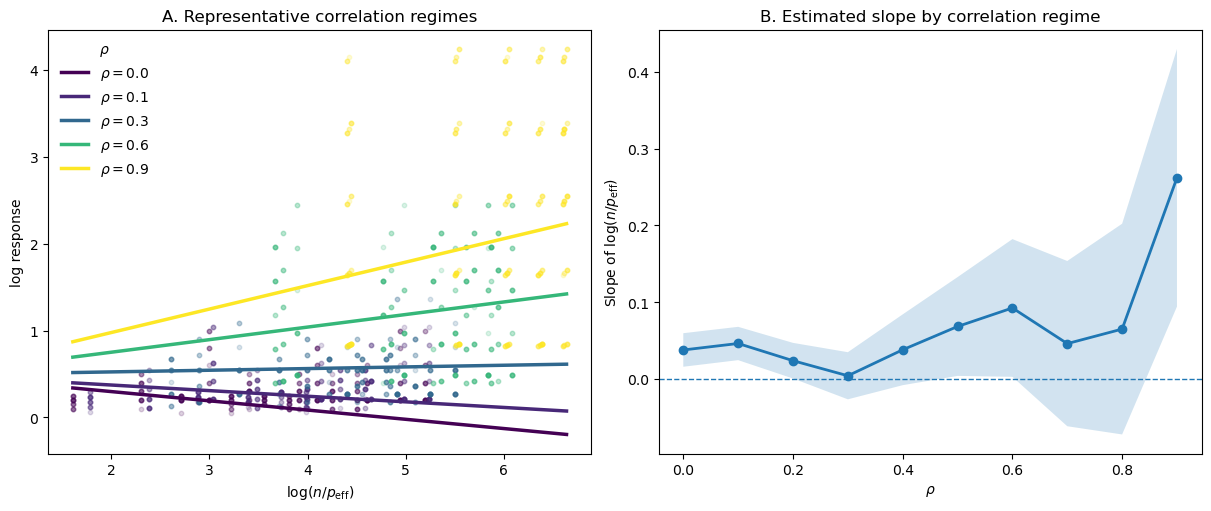

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import statsmodels.formula.api as smf

# ---------- settings ----------
rep_corr_levels = [0.0, .1, 0.3, 0.6, 0.9]   # panel A
all_corr_levels = sorted(df["corr"].unique())  # panel B

# color map shared across both panels
colors_all = cm.viridis(np.linspace(0, 1, len(all_corr_levels)))
color_map = dict(zip(all_corr_levels, colors_all))

# x-grid for prediction lines
log_ratio_vals = np.linspace(df["log_ratio"].min(), df["log_ratio"].max(), 200)

# ---------- compute slopes for panel B ----------
slope_rows = []

for c in all_corr_levels:
    subset = df[df["corr"] == c].copy()
    model_sub = smf.ols("mtry_p_eff~ log_ratio", data=subset).fit()
    
    slope_rows.append({
        "corr": c,
        "slope": model_sub.params["log_ratio"],
        "se": model_sub.bse["log_ratio"],
        "pval": model_sub.pvalues["log_ratio"]
    })

slope_df = pd.DataFrame(slope_rows)
slope_df["lower"] = slope_df["slope"] - 1.96 * slope_df["se"]
slope_df["upper"] = slope_df["slope"] + 1.96 * slope_df["se"]

# ---------- build figure ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# ===== Panel A: representative regimes =====
ax = axes[0]

for c in rep_corr_levels:
    subset = df[df["corr"] == c].copy()
    
    # scatter
    ax.scatter(
        subset["log_ratio"],
        subset["mtry_p_eff"],
        color=color_map[c],
        alpha=0.18,
        s=10
    )
    
    # fitted line from main interaction model
    temp_df = pd.DataFrame({
        "log_ratio": log_ratio_vals,
        "corr": np.repeat(c, len(log_ratio_vals))
    })
    preds = model_loglog.predict(temp_df)
    
    ax.plot(
        log_ratio_vals,
        preds,
        color=color_map[c],
        linewidth=2.5,
        label=fr"$\rho={c}$"
    )

ax.set_title("A. Representative correlation regimes")
ax.set_xlabel(r"$\log(n/p_{\mathrm{eff}})$")
ax.set_ylabel("log response")
ax.legend(title=r"$\rho$", frameon=False)

# ===== Panel B: slope vs correlation =====
ax = axes[1]

ax.plot(
    slope_df["corr"],
    slope_df["slope"],
    linewidth=2,
    marker="o"
)

ax.fill_between(
    slope_df["corr"],
    slope_df["lower"],
    slope_df["upper"],
    alpha=0.2
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_title("B. Estimated slope by correlation regime")
ax.set_xlabel(r"$\rho$")
ax.set_ylabel(r"Slope of $\log(n/p_{\mathrm{eff}})$")

# ---------- save ----------
plt.savefig("two_panel_scaling_figure.pdf", bbox_inches="tight")
plt.show()

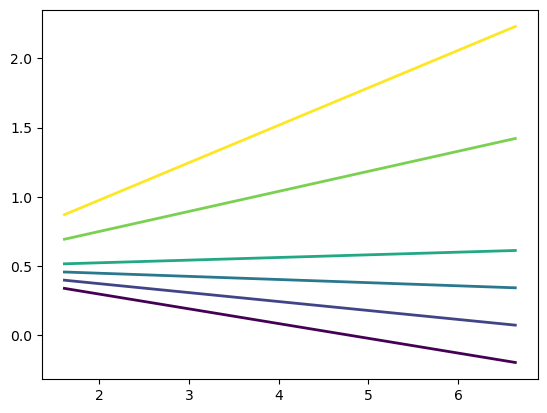

In [17]:
 import matplotlib.cm as cm
import numpy as np
corr_levels = [0.0, 0.1, 0.2, 0.3, 0.6, 0.9]
colors = cm.viridis(np.linspace(0, 1, len(corr_levels)))

for c, col in zip(corr_levels, colors):
    temp_df = pd.DataFrame({
        "log_ratio": log_ratio_vals,
        "corr": np.repeat(c, len(log_ratio_vals))
    })
    
    preds = model_loglog.predict(temp_df)
    plt.plot(log_ratio_vals, preds, color=col, linewidth=2, label=f"ρ = {c}")

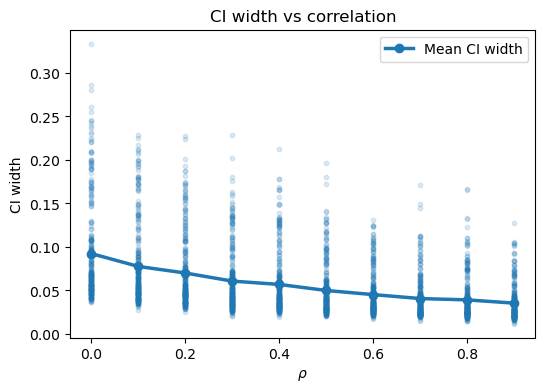

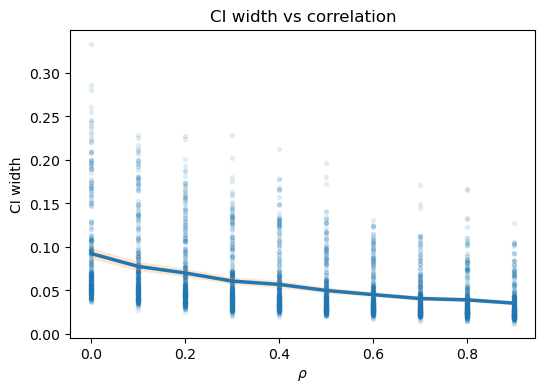

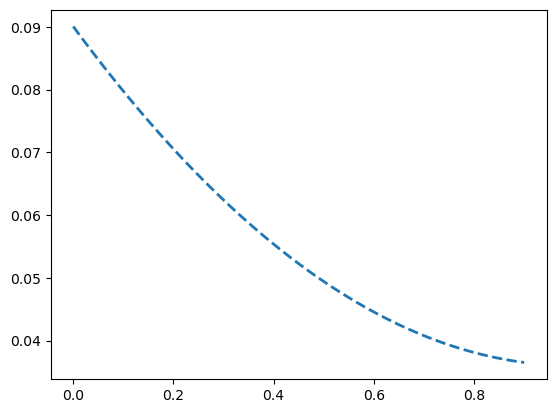

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
model_ci = smf.ols(
    "ci_width ~ corr+corrquad",
    data=df
).fit()

# group means
mean_df = df.groupby("corr")["ci_width"].mean().reset_index()

plt.figure(figsize=(6,4))

# scatter (light)
plt.scatter(df["corr"], df["ci_width"],
            alpha=0.15, s=10)

# mean trend (this is key)
plt.plot(mean_df["corr"], mean_df["ci_width"],
         linewidth=2.5, marker="o", label="Mean CI width")

plt.xlabel(r"$\rho$")
plt.ylabel("CI width")
plt.title("CI width vs correlation")

plt.legend()
plt.savefig("ci_vs_corr.pdf", bbox_inches="tight")
plt.show()
# compute mean + SE
summary = df.groupby("corr")["ci_width"].agg(["mean", "std", "count"]).reset_index()
summary["se"] = summary["std"] / np.sqrt(summary["count"])
summary["lower"] = summary["mean"] - 1.96 * summary["se"]
summary["upper"] = summary["mean"] + 1.96 * summary["se"]

plt.figure(figsize=(6,4))

# scatter
plt.scatter(df["corr"], df["ci_width"],
            alpha=0.1, s=8)

# mean line
plt.plot(summary["corr"], summary["mean"],
         linewidth=2.5)

# confidence band
plt.fill_between(summary["corr"],
                 summary["lower"],
                 summary["upper"],
                 alpha=0.2)

plt.xlabel(r"$\rho$")
plt.ylabel("CI width")
plt.title("CI width vs correlation")

plt.savefig("ci_vs_corr.pdf", bbox_inches="tight")
plt.show()

corr_grid = np.linspace(0, 0.9, 100)
pred_df = pd.DataFrame({"corr": corr_grid})
pred_df["corrquad"] = pred_df["corr"]**2

preds = model_ci.predict(pred_df)

plt.plot(corr_grid, preds, linestyle="--", linewidth=2,
         label="Quadratic fit")

/opt/conda/lib/python3.11/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


AttributeError: Line2D.set() got an unexpected keyword argument 'cmap'

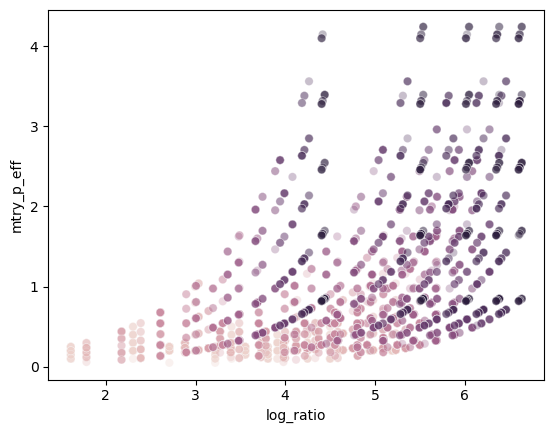

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
df["mtry_p_eff"]=df["selected_mtry"]/df["p_eff"]
df["ratio_np"] = df["n"] / df["p_eff"]
df["log_ratio"]=np.log(df["ratio_np"])
sns.scatterplot(
    data=df,
    x="log_ratio",
    y="mtry_p_eff",
    hue="corr",
    alpha=0.3
)

sns.regplot(
    data=df,
    x="log_ratio",
    y="mtry_p_eff",
    scatter=False,
    color="black"
)

plt.title("Linearity check")
plt.show()

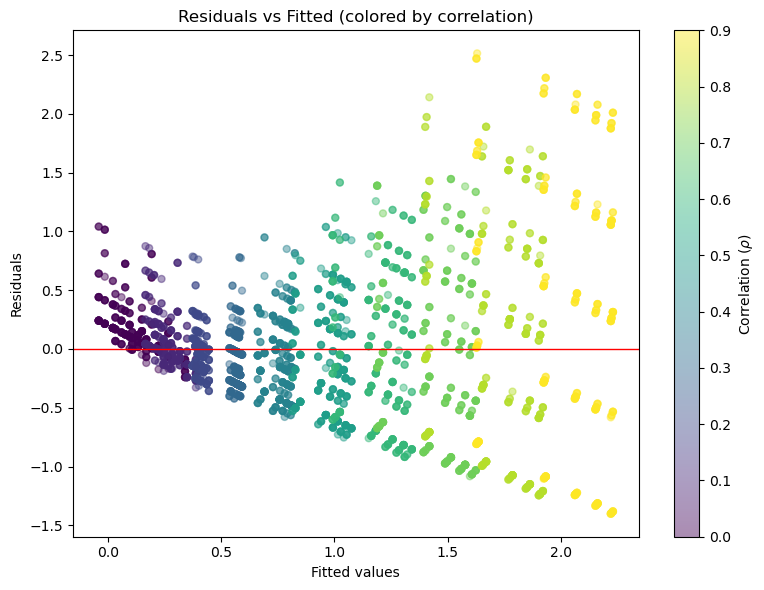

In [19]:
model_loglog = smf.ols(
    "mtry_p_eff ~ log_ratio*corr",
    data=df
).fit()
import seaborn as sns


df["fitted"]=model_loglog.fittedvalues
df["resid"]=model_loglog.resid

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

fig, ax = plt.subplots(figsize=(8, 6))

norm = Normalize(vmin=0.0, vmax=0.9)  # match your simulation range

sc = ax.scatter(
    df["fitted"],
    df["resid"],
    c=df["corr"],
    cmap="viridis",
    norm=norm,
    s=25,
    alpha=0.45
)

ax.axhline(0, color="red", linewidth=1)

ax.set_title("Residuals vs Fitted (colored by correlation)")
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Correlation ($\\rho$)")

plt.tight_layout()
plt.show()
fig.savefig("Residuals.pdf", dpi=300, bbox_inches='tight')

In [4]:
model_robust = model_loglog.get_robustcov_results(cov_type="HC3")
print(model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:             mtry_p_eff   R-squared:                       0.504
Model:                            OLS   Adj. R-squared:                  0.504
Method:                 Least Squares   F-statistic:                     828.6
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        06:49:17   Log-Likelihood:                -2781.0
No. Observations:                3000   AIC:                             5570.
Df Residuals:                    2996   BIC:                             5594.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.5109      0.052      9.

In [13]:
import statsmodels.stats.api as sms

bp_test = sms.het_breuschpagan(model_loglog.resid, model_loglog.model.exog)
print("BP p-value:", bp_test[1])

BP p-value: 1.6264142977566145e-191


In [15]:
 from statsmodels.stats.diagnostic import linear_reset

reset_test = linear_reset(model_loglog, power=2, use_f=True)
print(reset_test)

<F test: F=107.43976477331623, p=9.300234928879924e-25, df_denom=3e+03, df_num=1>


In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path
outdir = Path("results")
outdir.mkdir(exist_ok=True)
sns.set(style="whitegrid")
plt.figure(figsize=(6, 6))
stats.probplot(model_loglog.resid, dist="norm", plot=ax)

ax.set_title("Q-Q Plot of Residuals")
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Sample Quantiles")

fig.tight_layout()

png_path = outdir / "qq_plot_residuals.png"
pdf_path = outdir / "qq_plot_residuals.pdf"

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

<Figure size 600x600 with 0 Axes>

In [33]:
import numpy as np

df["log_n_over_peff"] = np.log(df["n"] / df["p_eff"])

# three versions of the response
df["mtry_raw"] = df["selected_mtry"]
df["mtry_over_p"] = df["selected_mtry"] / df["p"]
df["mtry_over_peff"] = df["selected_mtry"] / df["p_eff"]

# for ntree (optional)
df["log_ntree"] = np.log(df["selected_ntree"])
import statsmodels.formula.api as smf

# raw mtry
model_raw = smf.ols(
    "mtry_raw ~ log_n_over_peff * corr",
    data=df
).fit()

# normalized by p
model_p = smf.ols(
    "mtry_over_p ~ log_n_over_peff * corr",
    data=df
).fit()

# normalized by peff (your main model)
model_peff = smf.ols(
    "mtry_over_peff ~ log_n_over_peff * corr",
    data=df
).fit()

print(model_raw.summary())
print(model_p.summary())
print(model_peff.summary())

                            OLS Regression Results                            
Dep. Variable:               mtry_raw   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     26.82
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           4.12e-17
Time:                        07:57:31   Log-Likelihood:                -5286.8
No. Observations:                3000   AIC:                         1.058e+04
Df Residuals:                    2996   BIC:                         1.061e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                4.3643 

In [36]:
from scipy.stats import spearmanr
def spearman_all_normalizations(df):
    rows = []
    
    for rho_val in sorted(df["corr"].unique()):
        sub = df[df["corr"] == rho_val]
        
        for yvar, label in [
            ("mtry_raw", "mtry"),
            ("mtry_over_p", "mtry/p"),
            ("mtry_over_peff", "mtry/peff")
        ]:
            corr, pval = spearmanr(
                sub["log_n_over_peff"],
                sub[yvar]
            )
            
            rows.append({
                "rho": rho_val,
                "normalization": label,
                "spearman_rho": corr,
                "p_value": pval
            })
    
    return pd.DataFrame(rows)


spearman_all = spearman_all_normalizations(df)
print(spearman_all)

    rho normalization  spearman_rho       p_value
0   0.0          mtry     -0.413561  8.002704e-14
1   0.0        mtry/p      0.145173  1.182512e-02
2   0.0     mtry/peff      0.145173  1.182512e-02
3   0.1          mtry     -0.281498  7.199119e-07
4   0.1        mtry/p      0.295495  1.851750e-07
5   0.1     mtry/peff      0.201877  4.343090e-04
6   0.2          mtry     -0.223177  9.671356e-05
7   0.2        mtry/p      0.196751  6.099329e-04
8   0.2     mtry/peff      0.048752  4.001286e-01
9   0.3          mtry     -0.188137  1.059203e-03
10  0.3        mtry/p      0.153866  7.589040e-03
11  0.3     mtry/peff      0.005435  9.253162e-01
12  0.4          mtry     -0.006392  9.122039e-01
13  0.4        mtry/p      0.233114  4.559954e-05
14  0.4     mtry/peff      0.083772  1.477663e-01
15  0.5          mtry      0.045621  4.311075e-01
16  0.5        mtry/p      0.222024  1.053046e-04
17  0.5     mtry/peff      0.119936  3.787693e-02
18  0.6          mtry      0.081129  1.610216e-01
